<a href="https://colab.research.google.com/github/truonggiaky71-rgb/BT_ca_nhan_FaceCNN/blob/main/Bt_c%C3%A1_nh%C3%A2n_Face_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image
from google.colab import drive
import os
import zipfile


In [34]:
local_zip = '/content/drive/MyDrive/Face_RAP001.zip'
extract_path = '/content/dataset'

with zipfile.ZipFile(local_zip, 'r') as zip_ref:
  zip_ref.extractall(extract_path)
dataset_path = "/content/dataset/Face_RAP001"

img_width, img_height = 180, 180
batch_size=128
train_datagen = ImageDataGenerator(
    rescale = 1/255,
    rotation_range = 30,
    width_shift_range =0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

train_generator = train_datagen.flow_from_directory(
    dataset_path ,
    target_size = (img_width, img_height),
    batch_size = batch_size,
    class_mode = "categorical"
)


Found 1635 images belonging to 26 classes.


In [35]:
num_classes = len(train_generator.class_indices)
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(img_width, img_height, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,650,330 (25.37 MB)

 Trainable params: 6,650,330 (25.37 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
epochs = 25
history = model.fit(
    train_generator,
    epochs=epochs
)

Epoch 1/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 42s 3s/step - accuracy: 0.0948 - loss: 3.2528
Epoch 2/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.1590 - loss: 2.9991
Epoch 3/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step - accuracy: 0.2398 - loss: 2.6197
Epoch 4/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.3437 - loss: 2.2291
Epoch 5/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step - accuracy: 0.3896 - loss: 1.9667
Epoch 6/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step - accuracy: 0.4771 - loss: 1.7246
Epoch 7/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step - accuracy: 0.5162 - loss: 1.5526
Epoch 8/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step - accuracy: 0.5541 - loss: 1.4373
Epoch 9/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step - accuracy: 0.6226 - loss: 1.2607
Epoch 10/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 40s 3s/step - accuracy: 0.6471 - loss: 1.1526
Epoch 11/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step - accuracy: 0.6581 - loss: 1.0855
Epoch 12/25
13/13 ━━━━━━━━━━━━━━━━━━━━ 34s 3s/step - accuracy: 0.6575 - lo

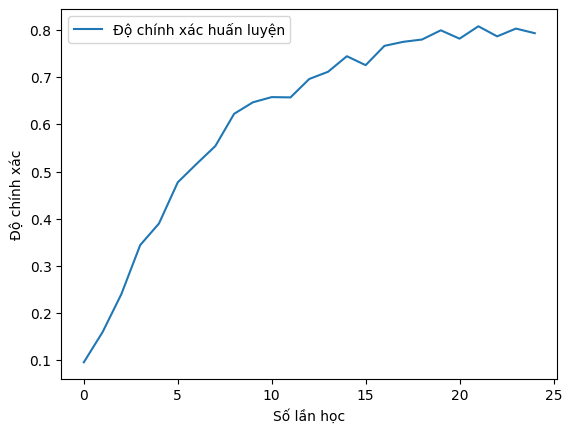

In [38]:
plt.plot(history.history['accuracy'], label="Độ chính xác huấn luyện")
plt.xlabel("Số lần học")
plt.ylabel("Độ chính xác")
plt.legend()
plt.show()

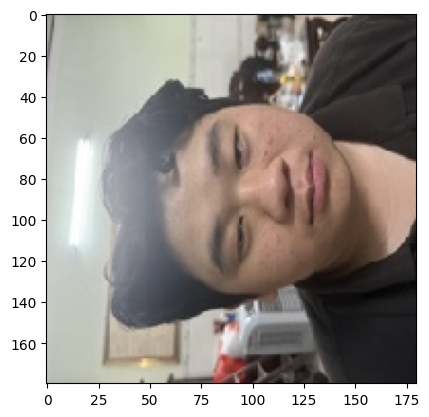

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
Người tiên đoán: Nguyễn Gia Kiên


In [51]:
from keras.utils import load_img
import numpy as np
path ="/content/dataset/Face_RAP001/Nguyễn Gia Kiên/IMG_0019.jpg"
# Tiên đoán loại s
img = load_img(path, target_size=(180, 180)) # Changed target_size to (180, 180)
plt.imshow(img)
plt.show()
img = np.array(img)
img = img / 255.0
img = img.reshape(1, 180, 180, 3) # Changed reshape to (1, 180, 180, 3)
prediction=np.argmax(model.predict(img))
# Ánh xạ loại tới tên người
class_labels = {v: k for k, v in train_generator.class_indices.items()}
person_name = class_labels[prediction]
print(f"Người tiên đoán: {person_name}")

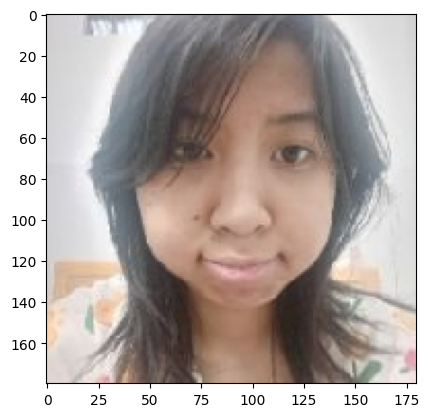

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Người tiên đoán: Lê Nguyễn Quỳnh Như


In [52]:
from keras.utils import load_img
import numpy as np
path ="/content/dataset/Face_RAP001/Lê Nguyễn Quỳnh Như/z7843741145735_c5c58c529f7ecc66002aad35d17edbe1.jpg"
# Tiên đoán loại s
img = load_img(path, target_size=(180, 180)) # Changed target_size to (180, 180)
plt.imshow(img)
plt.show()
img = np.array(img)
img = img / 255.0
img = img.reshape(1, 180, 180, 3) # Changed reshape to (1, 180, 180, 3)
prediction=np.argmax(model.predict(img))
# Ánh xạ loại tới tên người
class_labels = {v: k for k, v in train_generator.class_indices.items()}
person_name = class_labels[prediction]
print(f"Người tiên đoán: {person_name}")

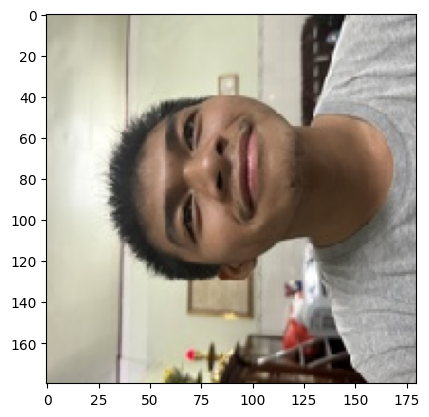

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
Người tiên đoán: Nguyễn Đức Minh


In [53]:
from keras.utils import load_img
import numpy as np
path ="/content/dataset/Face_RAP001/Nguyễn Đức Minh/IMG_9971.jpg"
# Tiên đoán loại s
img = load_img(path, target_size=(180, 180)) # Changed target_size to (180, 180)
plt.imshow(img)
plt.show()
img = np.array(img)
img = img / 255.0
img = img.reshape(1, 180, 180, 3) # Changed reshape to (1, 180, 180, 3)
prediction=np.argmax(model.predict(img))
# Ánh xạ loại tới tên người
class_labels = {v: k for k, v in train_generator.class_indices.items()}
person_name = class_labels[prediction]
print(f"Người tiên đoán: {person_name}")

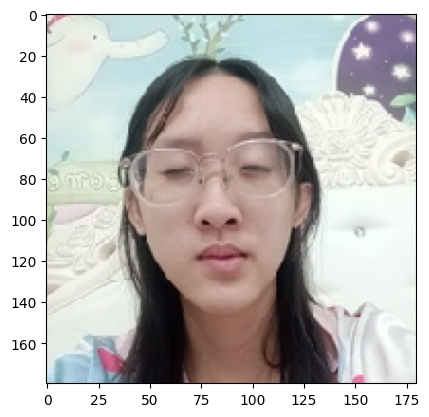

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Người tiên đoán: Nguyễn Phương Mai


In [54]:
from keras.utils import load_img
import numpy as np
path ="/content/dataset/Face_RAP001/Nguyễn Phương Mai/IMG_20260519_233312.jpg"
# Tiên đoán loại s
img = load_img(path, target_size=(180, 180)) # Changed target_size to (180, 180)
plt.imshow(img)
plt.show()
img = np.array(img)
img = img / 255.0
img = img.reshape(1, 180, 180, 3) # Changed reshape to (1, 180, 180, 3)
prediction=np.argmax(model.predict(img))
# Ánh xạ loại tới tên người
class_labels = {v: k for k, v in train_generator.class_indices.items()}
person_name = class_labels[prediction]
print(f"Người tiên đoán: {person_name}")

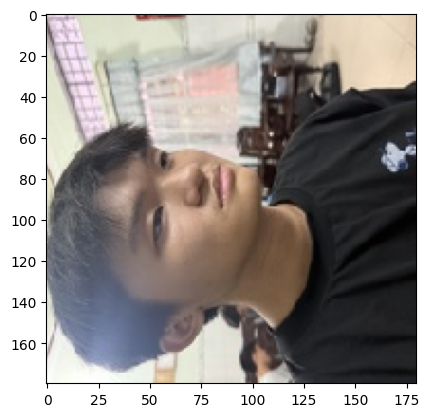

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Người tiên đoán: Vũ Minh Khương


In [55]:
from keras.utils import load_img
import numpy as np
path ="/content/dataset/Face_RAP001/Vũ Minh Khương/IMG_9884.jpg"
# Tiên đoán loại s
img = load_img(path, target_size=(180, 180)) # Changed target_size to (180, 180)
plt.imshow(img)
plt.show()
img = np.array(img)
img = img / 255.0
img = img.reshape(1, 180, 180, 3) # Changed reshape to (1, 180, 180, 3)
prediction=np.argmax(model.predict(img))
# Ánh xạ loại tới tên người
class_labels = {v: k for k, v in train_generator.class_indices.items()}
person_name = class_labels[prediction]
print(f"Người tiên đoán: {person_name}")